## Cell 1 – Import libraries & set seed

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm  # optional, untuk progress bar

# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Cell 2 – Part A1: Tensor operations & shapes

### Part A1 – Tensor operations and shapes

In [2]:
# Buat tensor contoh
t1 = torch.rand(3)          # shape (3,)
t2 = torch.rand(3, 4)       # shape (3,4)
t3 = torch.rand(4, 3)       # shape (4,3)

print("t1:", t1.shape)
print("t2:", t2.shape)
print("t3:", t3.shape)

# Matrix multiplication
print("\nMatrix mul (t2 @ t3):", (t2 @ t3).shape)

# Element-wise
print("Element-wise (t1 * t1):", (t1 * t1).shape)

# Broadcasting
print("Broadcasting (t1.unsqueeze(1) + t2):", (t1.unsqueeze(1) + t2).shape)

# Reshape / view
print("Reshape t2 → (2,6):", t2.view(2, 6).shape)

# Permute
print("Permute t2 → (4,3):", t2.permute(1, 0).shape)

# Flatten
print("Flatten t2:", t2.flatten().shape)

t1: torch.Size([3])
t2: torch.Size([3, 4])
t3: torch.Size([4, 3])

Matrix mul (t2 @ t3): torch.Size([3, 3])
Element-wise (t1 * t1): torch.Size([3])
Broadcasting (t1.unsqueeze(1) + t2): torch.Size([3, 4])
Reshape t2 → (2,6): torch.Size([2, 6])
Permute t2 → (4,3): torch.Size([4, 3])
Flatten t2: torch.Size([12])


### Part A2 – Autograd sanity check

### Let y = (w x + b)²
### dy/dw = 2 (w x + b) * x
### dy/db = 2 (w x + b) * 1

In [3]:
x = torch.tensor(1.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

y = (w * x + b) ** 2
y.backward()

print("Autograd:")
print(f"  dy/dw = {w.grad.item():.4f}")
print(f"  dy/db = {b.grad.item():.4f}")
print(f"  dy/dx = {x.grad.item():.4f}")

# Manual
val = w.item() * x.item() + b.item()
manual_dw = 2 * val * x.item()
manual_db = 2 * val
manual_dx = 2 * val * w.item()

print("\nManual:")
print(f"  dy/dw = {manual_dw:.4f}")
print(f"  dy/db = {manual_db:.4f}")
print(f"  dy/dx = {manual_dx:.4f}")

print("\nMatch?" , all(abs(a - b) < 1e-6 for a,b in zip([w.grad, b.grad, x.grad], [manual_dw, manual_db, manual_dx])))

Autograd:
  dy/dw = 10.0000
  dy/db = 10.0000
  dy/dx = 20.0000

Manual:
  dy/dw = 10.0000
  dy/db = 10.0000
  dy/dx = 20.0000

Match? True


## Cell 4 – Part B1 & B3: Load CIFAR-10 + Normalize

### Part B – Load CIFAR-10 + Preprocessing (Normalization)

In [4]:
# CIFAR-10 standard normalization
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD  = [0.2470, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
])

# Load full dataset
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split train → train + val (80:20)
train_size = int(0.8 * len(train_full))
val_size   = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size])

print(f"Train: {len(train_set):5d}  |  Val: {len(val_set):5d}  |  Test: {len(test_set):5d}")
print("Classes:", train_full.classes)

# Contoh DataLoader (akan di-redefine per eksperimen jika batch size beda)
def get_loaders(batch_size=64, num_workers=2):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

# Tes satu batch
train_loader, _, _ = get_loaders(64)
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape, labels.shape)

Train: 40000  |  Val: 10000  |  Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch shape: torch.Size([64, 3, 32, 32]) torch.Size([64])


### Part B2 – Explore & visualize

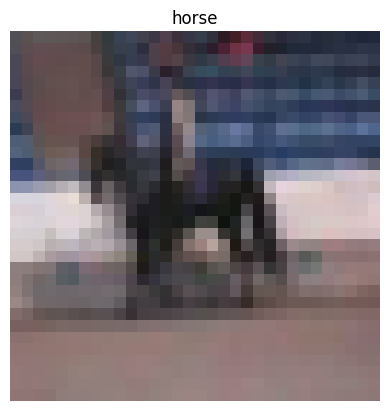

In [5]:
# Cell for visualization – fixed version

# 1. Single example image
img, lbl = train_set[0]           # img shape: (3,32,32)

# Denormalize correctly
mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)   # (3,1,1)
std  = torch.tensor(CIFAR_STD).view(3, 1, 1)    # (3,1,1)

img_denorm = img * std + mean                     # broadcasting works perfectly
img_denorm = img_denorm.clamp(0, 1)               # keep in [0,1]

plt.imshow(img_denorm.permute(1, 2, 0))           # now (32,32,3)
plt.title(train_full.classes[lbl])
plt.axis('off')
plt.show()

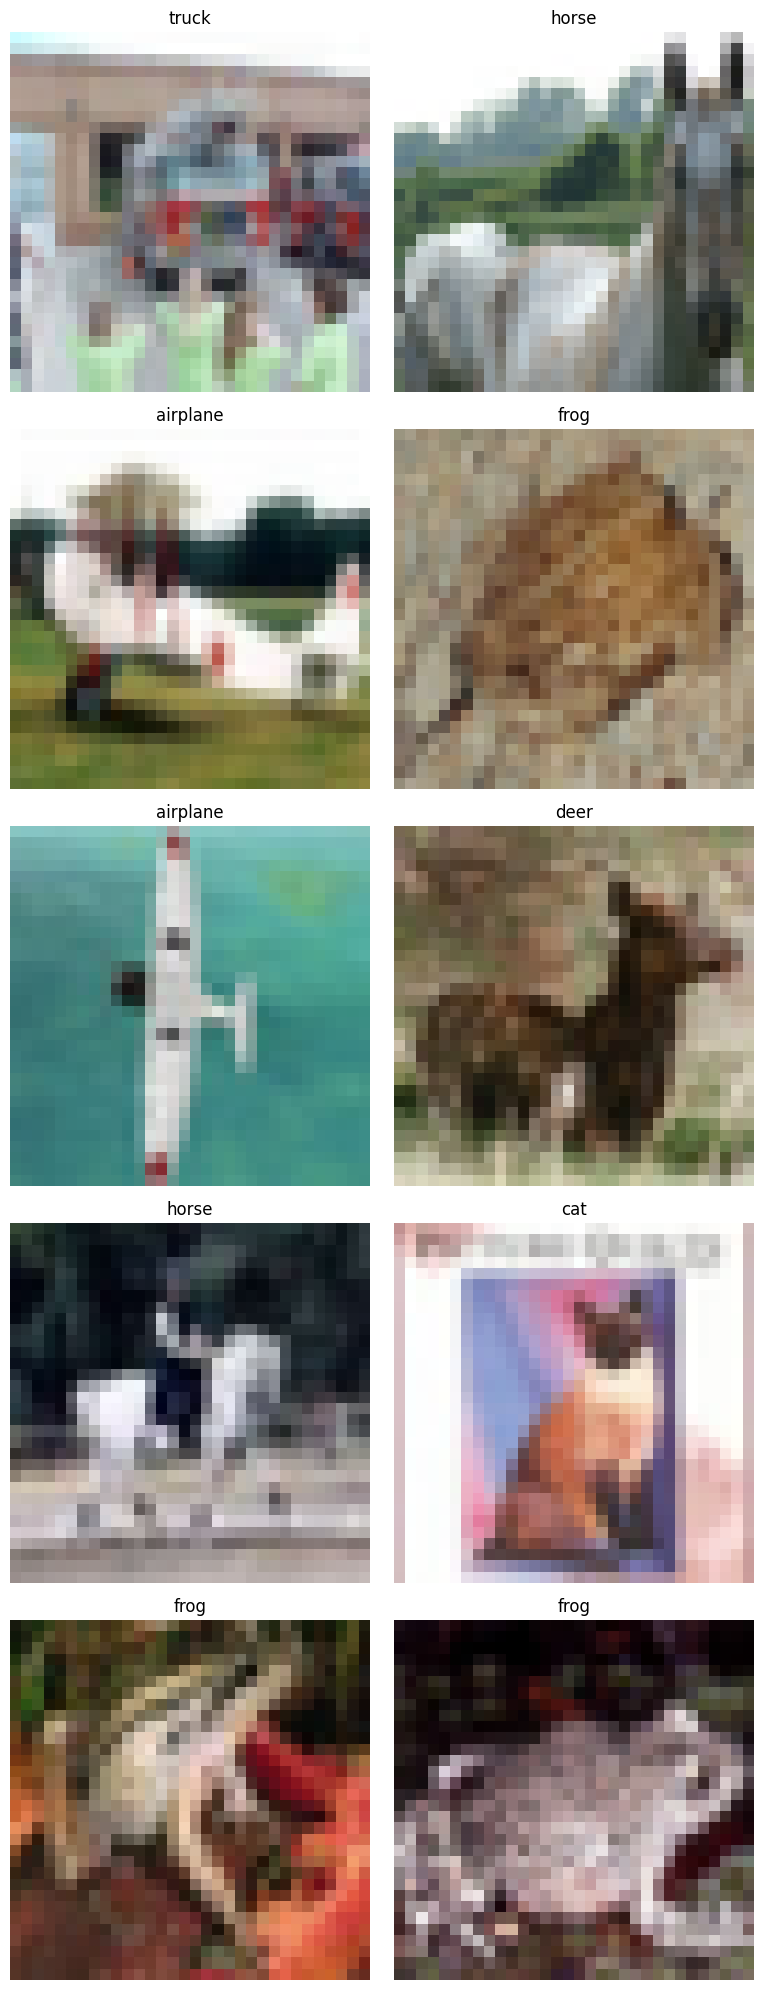

In [6]:
# Grid 5×2 – fixed
fig, axes = plt.subplots(5, 2, figsize=(8, 20))
axes = axes.flat

mean_t = torch.tensor(CIFAR_MEAN).view(3,1,1)
std_t  = torch.tensor(CIFAR_STD).view(3,1,1)

for i in range(10):
    idx = np.random.randint(len(train_set))
    img, lbl = train_set[idx]

    img_show = img * std_t + mean_t
    img_show = img_show.clamp(0, 1).permute(1, 2, 0)

    axes[i].imshow(img_show)
    axes[i].set_title(train_full.classes[lbl])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

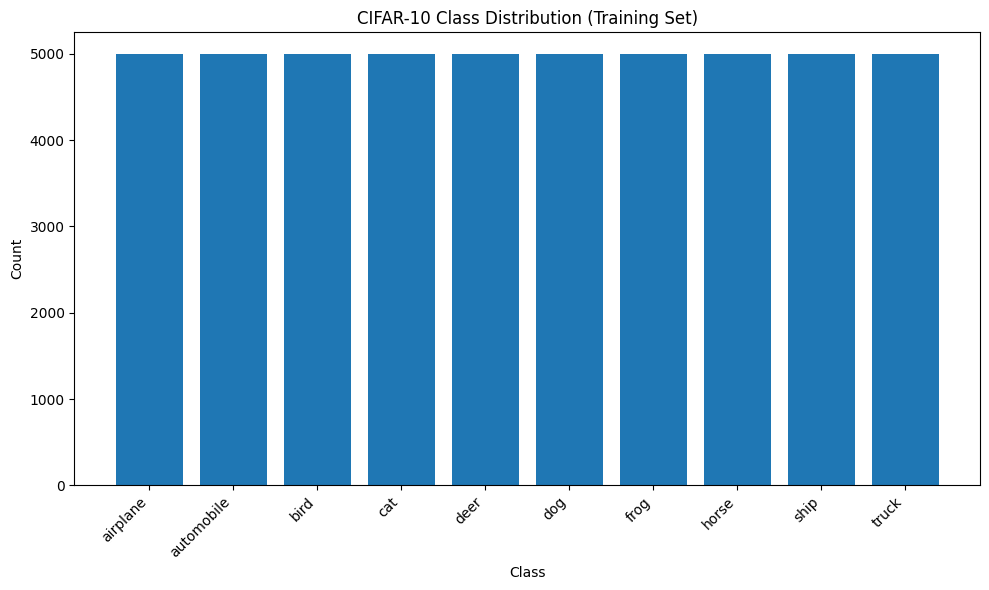

In [7]:
labels = [label for _, label in train_full]
class_counts = torch.tensor(labels).bincount(minlength=len(train_full.classes))

plt.figure(figsize=(10, 6))
plt.bar(train_full.classes, class_counts.numpy())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("CIFAR-10 Class Distribution (Training Set)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Cell 6 – Part C1: Baseline Model

### Part C1 – Baseline MLP

In [8]:
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

print(BaselineMLP())

BaselineMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Cell 7 – Training & Evaluation functions

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

## Cell 8 – Part C2 & C3: Train baseline + show params & hyperparams

## Part C – Baseline training + Parameters vs Hyperparameters

Train:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch  1 | Train loss: 1.6764 | Train acc: 0.4046 | Val acc: 0.4477


Train:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch  2 | Train loss: 1.4734 | Train acc: 0.4789 | Val acc: 0.4772


Train:   0%|          | 0/625 [00:00<?, ?it/s]

...

Train:   0%|          | 0/625 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8102c19c60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8102c19c60>if w.is_alive():

Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()  
 ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():
^ ^ ^ ^ ^   ^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
 ^  ^  ^^   ^ ^^ 
   File "/usr

Epoch 19 | Train loss: 0.5592 | Train acc: 0.8011 | Val acc: 0.5050


Train:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 20 | Train loss: 0.5114 | Train acc: 0.8176 | Val acc: 0.5022


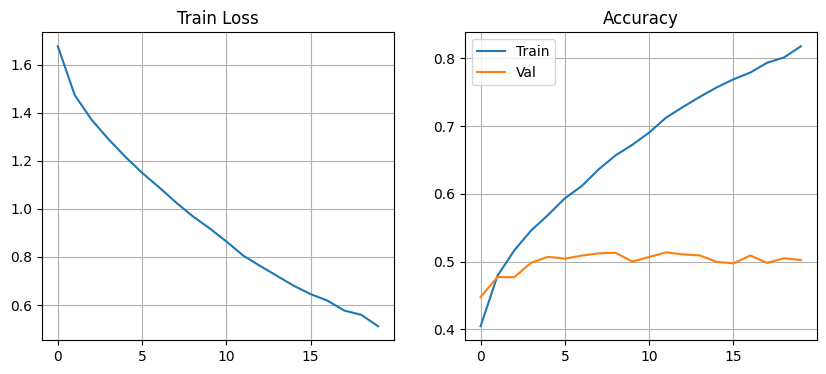

Best val acc: 0.5136 @ epoch 12


In [10]:
model = BaselineMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loader, val_loader, _ = get_loaders(batch_size=64)

epochs = 20  # ubah ke 5-10 jika testing
train_losses, train_accs, val_accs = [], [], []

best_val_acc = 0.0
best_epoch = 0

for epoch in range(epochs):
    try:
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion)

        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)

        print(f"Epoch {epoch+1:2d} | Train loss: {tr_loss:.4f} | Train acc: {tr_acc:.4f} | Val acc: {va_acc:.4f}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), "best_baseline.pth")

    except KeyboardInterrupt:
        print("Training dihentikan manual.")
        break

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Train Loss"); plt.grid(True)
plt.subplot(1,2,2); plt.plot(train_accs, label="Train"); plt.plot(val_accs, label="Val")
plt.title("Accuracy"); plt.legend(); plt.grid(True)
plt.show()

print(f"Best val acc: {best_val_acc:.4f} @ epoch {best_epoch}")

In [11]:
# Parameters
print("=== Parameters ===")
total = 0
for name, p in model.named_parameters():
    if p.requires_grad:
        n = p.numel()
        print(f"{name:24} {list(p.shape)} → {n:,} params")
        total += n
print(f"\nTotal trainable parameters: {total:,}")

# Hyperparameters table
hyper = {
    "Learning rate": 0.001,
    "Batch size": 64,
    "Optimizer": "Adam",
    "Epochs": epochs,
    "Hidden": "256 → 128",
    "Activation": "ReLU",
    "Weight decay": 0.0
}

df_hyper = pd.DataFrame(list(hyper.items()), columns=["Hyperparameter", "Value"])
display(df_hyper)

=== Parameters ===
net.1.weight             [256, 3072] → 786,432 params
net.1.bias               [256] → 256 params
net.3.weight             [128, 256] → 32,768 params
net.3.bias               [128] → 128 params
net.5.weight             [10, 128] → 1,280 params
net.5.bias               [10] → 10 params

Total trainable parameters: 820,874


,Hyperparameter,Value
0,Learning rate,0.001
1,Batch size,64
2,Optimizer,Adam
3,Epochs,20
4,Hidden,256 → 128
5,Activation,ReLU
6,Weight decay,0.0


## Cell 9 – Part D: Eksperimen (modular)

### Part D – Experiments

In [12]:
def run_experiment(model_class, hyper_dict, run_name="exp"):
    print(f"\n=== Running {run_name} ===")
    print(hyper_dict)

    torch.manual_seed(SEED)
    model = model_class().to(device)

    opt_class = hyper_dict.get("optimizer", optim.Adam)
    lr = hyper_dict["lr"]
    wd  = hyper_dict.get("weight_decay", 0.0)
    bs  = hyper_dict["batch_size"]
    epochs = hyper_dict["epochs"]

    optimizer = opt_class(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    train_l, val_l, _ = get_loaders(batch_size=bs)

    best_va = 0.0
    history = {"val_acc": []}

    for ep in range(epochs):
        try:
            tr_l, tr_a = train_epoch(model, train_l, optimizer, criterion)
            _, va_a = eval_epoch(model, val_l, criterion)
            history["val_acc"].append(va_a)
            print(f"  Epoch {ep+1:2d}  val acc: {va_a:.4f}")
            if va_a > best_va:
                best_va = va_a
        except KeyboardInterrupt:
            print("  Interrupted.")
            break

    final_va = history["val_acc"][-1] if history["val_acc"] else 0.0
    return best_va, final_va, epochs * 1.2   # estimasi waktu ~1.2 menit/epoch di CPU

In [13]:
# Definisi model varian
class WiderMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512), nn.ReLU(),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

class DeeperMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

In [14]:
# Jalankan semua eksperimen (ubah epochs jika ingin cepat)
results = []

baseline_hyper = {"lr":0.001, "batch_size":64,  "epochs":20, "optimizer":optim.Adam, "weight_decay":0.0}
results.append( ("Baseline", baseline_hyper, *run_experiment(BaselineMLP, baseline_hyper, "Baseline")) )

# Contoh eksperimen lain (tambahkan sesuai kebutuhan)
exp_list = [
    ("LR 3e-4",   {**baseline_hyper, "lr":3e-4}),
    ("LR 3e-3",   {**baseline_hyper, "lr":3e-3}),
    ("Batch 128", {**baseline_hyper, "batch_size":128}),
    ("Wider",     {**baseline_hyper, "model":WiderMLP}),
    ("Deeper",    {**baseline_hyper, "model":DeeperMLP}),
]

for name, h in exp_list:
    model_cls = h.pop("model", BaselineMLP)
    best, final, time_est = run_experiment(model_cls, h, name)
    results.append( (name, h, best, final, time_est) )


=== Running Baseline ===
{'lr': 0.001, 'batch_size': 64, 'epochs': 20, 'optimizer': <class 'torch.optim.adam.Adam'>, 'weight_decay': 0.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch  1  val acc: 0.4423


Train:   0%|          | 0/625 [00:00<?, ?it/s]

...

  Epoch 18  val acc: 0.5136


Train:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 19  val acc: 0.5117


Train:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 20  val acc: 0.5040


## Cell 10 – Part D3: Comparison Table

## Part D3 – Comparison Table

In [15]:
rows = []
for name, h, best_acc, final_acc, time_est in results:
    row = {
        "Run": name,
        "Model": "Wider" if "Wider" in name else "Deeper" if "Deeper" in name else "Baseline",
        "LR": h["lr"],
        "Batch": h["batch_size"],
        "Optimizer": h.get("optimizer", optim.Adam).__name__,
        "WD": h.get("weight_decay", 0.0),
        "Best Val Acc": best_acc,
        "Final Val Acc": final_acc,
        "Est. Time (min)": round(time_est,1)
    }
    rows.append(row)

df = pd.DataFrame(rows)
df = df.round({"Best Val Acc":4, "Final Val Acc":4})
display(df.sort_values("Best Val Acc", ascending=False))

,Run,Model,LR,Batch,Optimizer,WD,Best Val Acc,Final Val Acc,Est. Time (min)
1,LR 3e-4,Baseline,0.0003,64,Adam,0.0,0.5348,0.5194,24.0
3,Batch 128,Baseline,0.0010,128,Adam,0.0,0.5229,0.4986,24.0
5,Deeper,Deeper,0.0010,64,Adam,0.0,0.5228,0.5040,24.0
4,Wider,Wider,0.0010,64,Adam,0.0,0.5209,0.5209,24.0
0,Baseline,Baseline,0.0010,64,Adam,0.0,0.5199,0.4980,24.0
2,LR 3e-3,Baseline,0.0030,64,Adam,0.0,0.4785,0.4754,24.0
